# Decision Transformer for Limit Order Book Trading

**Authors:** Côme Genet & Clément Callaer — CentraleSupélec, 2026

---

This project explores an **Offline Reinforcement Learning** approach to financial market trading by framing the RL problem as a **conditional sequence modeling task**. Instead of relying on traditional value-based methods (TD learning, policy gradients), we implement a **Decision Transformer** architecture built from scratch in PyTorch.

## 1. Finance Background: what is a Limit Order Book?

A **Limit Order Book (LOB)** is the electronic table used by an exchange to match buyers and sellers.

- A **bid** is an intention to buy at a given price.
- An **ask** is an intention to sell at a given price.
- Orders are organized by **price level**: level 1 is the best currently available price, level 2 the next best, and so on.

At time $t$, the best prices are:

$$
 p_b^{(1)}(t) = \text{best bid}, \qquad p_a^{(1)}(t) = \text{best ask}
$$

The **mid-price** is the average of the two and is often used as a reference price:

$$
 m_t = \frac{p_a^{(1)}(t) + p_b^{(1)}(t)}{2}
$$

The **spread** measures the distance between buyers and sellers:

$$
 s_t = p_a^{(1)}(t) - p_b^{(1)}(t)
$$

Each level also has an available **volume**:

$$
 v_a^{(i)}(t), \; v_b^{(i)}(t), \qquad i = 1, \dots, 10
$$

So one snapshot of the book contains price and volume information on both sides:

$$
 x_t = \left[p_a^{(1)}, v_a^{(1)}, p_b^{(1)}, v_b^{(1)}, \dots, p_a^{(10)}, v_a^{(10)}, p_b^{(10)}, v_b^{(10)}\right]
$$

This is the core object studied in high-frequency finance: instead of only observing the traded price, we observe the **supply and demand close to the market price**.

A useful intuition is that the LOB is a very short-term picture of market pressure:
- more buy volume near the best bid can indicate upward pressure,
- more sell volume near the best ask can indicate downward pressure,
- a narrow spread usually indicates better liquidity.

One classical feature is the **imbalance** at the best level:

$$
 I_t = \frac{v_b^{(1)}(t)}{v_a^{(1)}(t) + v_b^{(1)}(t)}
$$

If $I_t$ is high, the buy side is relatively stronger; if it is low, the sell side is relatively stronger. This is one example of a microstructure feature that can help predict short-term price moves.

## 2. Dataset — FI-2010 Limit Order Book

The **FI-2010** benchmark dataset, introduced in `arXiv 1705.03233`, is one of the first public benchmark datasets for **mid-price prediction from LOB data**. It contains high-frequency order book data for **5 Finnish stocks** over **10 consecutive trading days** from the Helsinki exchange.

This matters because most real LOB datasets are proprietary. FI-2010 became a standard benchmark precisely because it makes reproducible experiments possible.

In the processed representation used here, each event is described by **149 rows**:

- **Rows 0-39:** raw LOB information for the first 10 levels
  $$
  10 \text{ levels} \times 4 \text{ values per level} = 40 \text{ raw features}
  $$
  with `ask price, ask volume, bid price, bid volume`.
- **Rows 40-143:** **104 engineered features** built from the raw book.
- **Rows 144-148:** labels for **5 prediction horizons**.

The full predictive vector therefore has **144 input features** before the label rows.

### What the engineered features represent

Following the dataset paper, the 104 engineered features are not arbitrary: they summarize economically meaningful properties of the book.

They include:
- **Spread and mid-price features**: how far bid and ask are from each other, and the current reference price.
- **Price difference features**: how prices change across levels of the book.
- **Average price and volume features**: summary statistics of liquidity on both sides.
- **Accumulated differences**: total buy-side versus sell-side pressure.
- **Time-sensitive derivatives**: how prices and volumes evolve over recent events.
- **Order-intensity features**: frequencies of submissions, cancellations, and executions.

For a non-finance audience, the key idea is simple: the dataset does not only store the current order book, it also stores **summaries of its geometry and recent dynamics**.

### Labels: what are we trying to predict?

The target is not the exact future price, but the **direction of the future mid-price movement**.

In the FI-2010 benchmark, labels are created from a smoothed future return:

$$
 l_t^{(k)} = \frac{\frac{1}{k}\sum_{j=t+1}^{t+k} m_j - m_t}{m_t}
$$

where $k$ is the prediction horizon in number of future events.

The label is then discretized into three classes:

$$
 y_t =
\begin{cases}
+1 & \text{if } l_t^{(k)} > \alpha \\
0 & \text{if } |l_t^{(k)}| \le \alpha \\
-1 & \text{if } l_t^{(k)} < -\alpha
\end{cases}
$$

So the machine learning task is a **3-class classification problem**: predict whether the mid-price will go **up**, **stay approximately unchanged**, or **go down**.

### Important dataset characteristics to mention in a presentation

For a professor not familiar with finance, these are the main takeaways:

- The data is **event-based**, not sampled every second. One observation corresponds to a book update.
- The market is represented through the **top 10 bid and ask levels**, not only the last traded price.
- The dataset is already **normalized**, because the original exchange data cannot be publicly released in raw form.
- The benchmark focuses on **very short-term forecasting** in market microstructure.
- The labels are based on the **mid-price**, which is more stable than transaction prices at ultra-high frequency.

We download the public benchmark version from Kaggle using `kagglehub`. 

## 3. Why the two papers matter for this project

### `arXiv 1705.03233` — the dataset paper

This paper is the reference for the **construction of FI-2010**. Its main contributions are:

- it releases a rare **public LOB benchmark**,
- it defines a reproducible **evaluation protocol**,
- it provides the **144-dimensional representation** and the 3-class labels,
- it shows baseline results for traditional machine learning models.

Conceptually, this paper answers: **what is the data, how is it built, and what exactly should be predicted?**

It also explains several finance-specific choices that are easy to miss:
- auction periods are treated separately because market behavior there is structurally different,
- event time is preferred to clock time because market activity is irregular,
- class imbalance makes **F1-score** more informative than accuracy alone.

### `arXiv 1808.03668` — the modelling paper (DeepLOB)

This paper starts from the FI-2010 benchmark and asks a different question: **can a neural network learn useful features directly from raw LOB states?**

Its main message is that hand-crafted features are helpful, but deep models can often learn better internal representations from the raw 40-dimensional LOB input over a short history window.

The paper uses sequences of LOB states:

$$
X_t \in \mathbb{R}^{100 \times 40}
$$

meaning that the model observes the **100 most recent book states**, each with **40 raw features**.

A key idea in DeepLOB is that convolutional layers can detect local price-volume patterns across levels, while LSTMs can capture temporal structure across recent events. In finance terms, the model tries to learn:
- local **supply-demand imbalances**,
- short-term **liquidity shocks**,
- recurring **microstructure patterns** that precede price changes.

The paper also highlights one important practical point: FI-2010 is very useful, but it is **small and highly processed** compared with real industrial datasets. So it is excellent for benchmarking, but not sufficient on its own to prove real-world trading robustness.

### Connection with our notebook

These two papers play complementary roles:

- `1705.03233` tells us **how the benchmark dataset is built** and how labels are defined.
- `1808.03668` tells us **why LOB data contains predictive structure** and how deep models can exploit it.

In other words:
- the first paper gives the **data representation and benchmark task**,
- the second paper gives a **modern learning architecture and interpretation of useful LOB features**.

That is why FI-2010 is still widely used in machine learning for finance: it provides a common testbed for comparing architectures, from classical models to deep sequence models.


## Project Roadmap

The goal of this notebook is to build a **Decision Transformer** agent that learns to trade on Limit Order Book data using **Offline Reinforcement Learning**. The full pipeline is:

1. **Import libraries** — load all dependencies (NumPy, PyTorch, etc.).
2. **Load the dataset** — download and parse the FI-2010 benchmark.
3. **Explore & preprocess the data** — inspect feature distributions, build state representations, and split into train/test.
4. **Define the trading environment** — formalize the state space, action space ($\{-1, 0, +1\}$), and reward function with transaction costs.
5. **Generate offline trajectories** — run a heuristic policy to produce $(s, a, r, \hat{R})$ sequences for offline training.
6. **Build the Decision Transformer** — implement the GPT-style architecture from scratch in PyTorch.
7. **Train the model** — optimize the sequence model on the offline dataset.
8. **Evaluate & backtest** — measure the agent's performance (cumulative PnL, Sharpe ratio, comparison with baselines).
9. **Analysis & visualization** — interpret the learned policy and present results.

---

## 4. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path
import os
import kagglehub

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"MPS available  : {torch.backends.mps.is_available()}")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device   : {device}")

PyTorch version: 2.11.0+cu130
CUDA available : True
MPS available  : False
Using device   : cuda


## 5. Load the Dataset

We download the FI-2010 benchmark from Kaggle using `kagglehub`, then load the **Z-score normalized, no-auction** variant — the standard setting used in most published benchmarks. The data files are concatenated along the time axis to form one large matrix of shape $(149, T)$ where $T$ is the total number of events across all cross-validation folds.

In [2]:
dataset_path = Path(kagglehub.dataset_download("ulfricirons/fi-2010"))
print(f"Dataset downloaded to: {dataset_path}")

for root, dirs, files in os.walk(dataset_path):
    for f in files:
        rel = os.path.relpath(os.path.join(root, f), dataset_path)
        print(f"  {rel}")

Dataset downloaded to: /home/calla/.cache/kagglehub/datasets/ulfricirons/fi-2010/versions/1
  BenchmarkDatasets/NoAuction/1.NoAuction_Zscore/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_1.txt
  BenchmarkDatasets/NoAuction/1.NoAuction_Zscore/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_3.txt
  BenchmarkDatasets/NoAuction/1.NoAuction_Zscore/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_7.txt
  BenchmarkDatasets/NoAuction/1.NoAuction_Zscore/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_4.txt
  BenchmarkDatasets/NoAuction/1.NoAuction_Zscore/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_5.txt
  BenchmarkDatasets/NoAuction/1.NoAuction_Zscore/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_6.txt
  BenchmarkDatasets/NoAuction/1.NoAuction_Zscore/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_2.txt
  BenchmarkDatasets/NoAuction/1.NoAuction_Zscore/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_8.txt
  BenchmarkDatasets/NoAuction/1.NoAu

In [3]:
# Load the Z-score normalized, no-auction data (standard benchmark setting)
# Adjust the glob pattern below if the directory structure differs after download.
zscore_files = sorted(dataset_path.rglob("*NoAuction_Zscore*/*.txt"))

if not zscore_files:
    # Fallback: try to find any .txt files
    zscore_files = sorted(dataset_path.rglob("*.txt"))
    print(f"Could not find NoAuction_Zscore folder — found {len(zscore_files)} .txt file(s) total.")

print(f"Found {len(zscore_files)} data file(s):")
for f in zscore_files:
    print(f"  {f.name}")

# Load all files and concatenate along the time axis (columns)
arrays = [np.loadtxt(f) for f in zscore_files]
data = np.hstack(arrays)  # shape: (149, total_timesteps)
print(f"\nCombined data shape: {data.shape}  (149 rows × {data.shape[1]} timesteps)")

Found 18 data file(s):
  Test_Dst_NoAuction_ZScore_CF_1.txt
  Test_Dst_NoAuction_ZScore_CF_2.txt
  Test_Dst_NoAuction_ZScore_CF_3.txt
  Test_Dst_NoAuction_ZScore_CF_4.txt
  Test_Dst_NoAuction_ZScore_CF_5.txt
  Test_Dst_NoAuction_ZScore_CF_6.txt
  Test_Dst_NoAuction_ZScore_CF_7.txt
  Test_Dst_NoAuction_ZScore_CF_8.txt
  Test_Dst_NoAuction_ZScore_CF_9.txt
  Train_Dst_NoAuction_ZScore_CF_1.txt
  Train_Dst_NoAuction_ZScore_CF_2.txt
  Train_Dst_NoAuction_ZScore_CF_3.txt
  Train_Dst_NoAuction_ZScore_CF_4.txt
  Train_Dst_NoAuction_ZScore_CF_5.txt
  Train_Dst_NoAuction_ZScore_CF_6.txt
  Train_Dst_NoAuction_ZScore_CF_7.txt
  Train_Dst_NoAuction_ZScore_CF_8.txt
  Train_Dst_NoAuction_ZScore_CF_9.txt

Combined data shape: (149, 2045191)  (149 rows × 2045191 timesteps)


In [4]:
# Separate LOB features and labels
lob_features = data[:40, :]       # 10 levels × 4 (ask_price, ask_vol, bid_price, bid_vol)
handcrafted   = data[40:144, :]   # 104 hand-crafted features
labels        = data[144:, :]     # 5 label rows for horizons k=10,20,30,50,100

print("LOB features shape :", lob_features.shape)
print("Hand-crafted shape :", handcrafted.shape)
print("Labels shape       :", labels.shape)

# Transpose to (timesteps, features) — standard ML convention
X_lob = lob_features.T
X_all = data[:144, :].T
y     = labels.T

print(f"\nFeature matrix (LOB only) : {X_lob.shape}  (timesteps × 40)")
print(f"Feature matrix (all feat.): {X_all.shape}  (timesteps × 144)")
print(f"Label matrix              : {y.shape}  (timesteps × 5 horizons)")

LOB features shape : (40, 2045191)
Hand-crafted shape : (104, 2045191)
Labels shape       : (5, 2045191)

Feature matrix (LOB only) : (2045191, 40)  (timesteps × 40)
Feature matrix (all feat.): (2045191, 144)  (timesteps × 144)
Label matrix              : (2045191, 5)  (timesteps × 5 horizons)


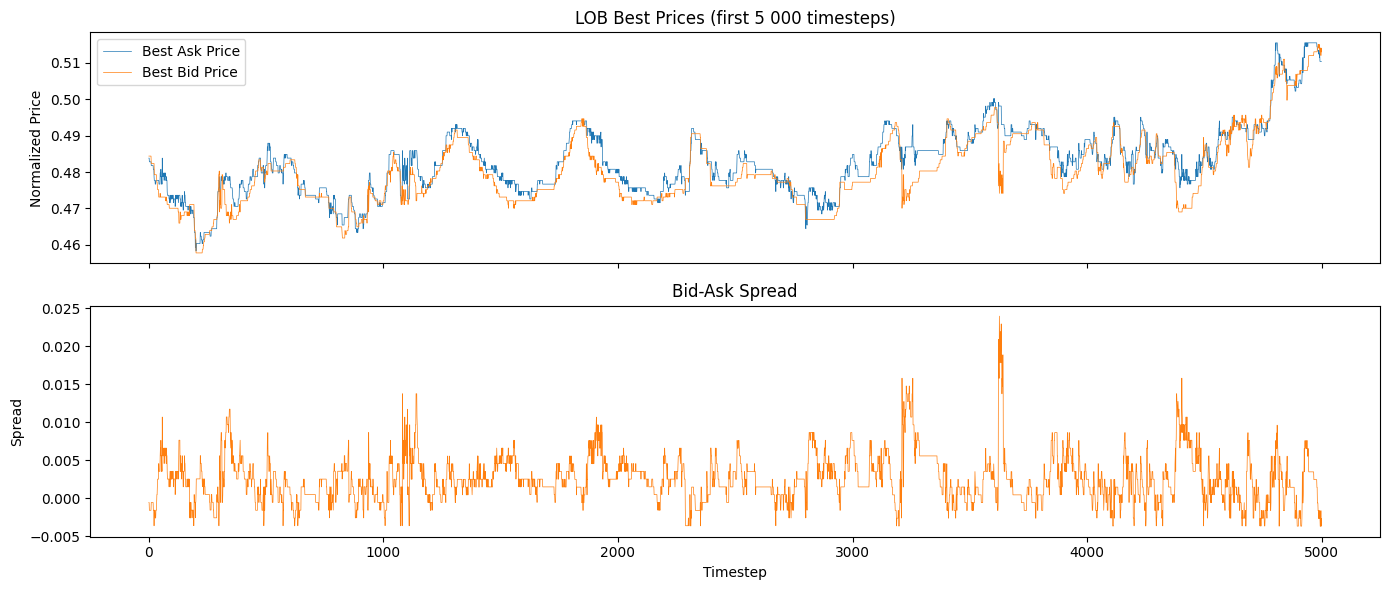

In [5]:
# Quick visualization: best ask & bid prices over time
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

n_display = min(5000, X_lob.shape[0])

axes[0].plot(X_lob[:n_display, 0], linewidth=0.5, label="Best Ask Price")
axes[0].plot(X_lob[:n_display, 2], linewidth=0.5, label="Best Bid Price")
axes[0].set_ylabel("Normalized Price")
axes[0].legend()
axes[0].set_title("LOB Best Prices (first 5 000 timesteps)")

spread = X_lob[:n_display, 0] - X_lob[:n_display, 2]
axes[1].plot(spread, linewidth=0.5, color="tab:orange")
axes[1].set_ylabel("Spread")
axes[1].set_xlabel("Timestep")
axes[1].set_title("Bid-Ask Spread")

plt.tight_layout()
plt.show()

## 6. Data Exploration and Preprocessing

### 6.1. The DeepLOB Framework: Raw Features

Let $\mathbf{x}_t \in \mathbb{R}^{40}$ denote the state of the Limit Order Book (LOB) at time $t$. Following the DeepLOB methodology (`arXiv 1808.03668`), we restrict our feature space to the raw LOB data. Specifically, for each of the $L=10$ price levels, we consider exactly 4 variables: the bid price, the bid volume, the ask price, and the ask volume. We deliberately discard the 104 hand-crafted features provided in the FI-2010 dataset. Indeed, the core premise of DeepLOB is that deep neural architectures are capable of learning optimal representations directly from the raw signal.

### 6.2. Time Series Properties and Splitting Strategy

LOB data constitutes a multivariate time series exhibiting strong temporal dependencies. Following the methodological guidelines of Boyer & Coudray (*Guidelines — Time Series*), we must rigorously address the following properties before modeling:

**1. Non-i.i.d. Observations:** The sequence of LOB snapshots $X = (\mathbf{x}_1, \dots, \mathbf{x}_T)$ does not consist of independent and identically distributed (i.i.d.) variables. The state $\mathbf{x}_t$ is highly correlated with $\mathbf{x}_{t-1}$ due to the incremental nature of order book dynamics.

**2. The Fallacy of Random Splitting:** A naive random train/test split introduces severe data leakage. If the dataset is randomly partitioned, the training set and test set will contain temporally adjacent samples. Consequently, a model may achieve an artificially low error by merely interpolating local patterns. Boyer & Coudray demonstrate this phenomenon: a random split can yield an artificial Mean Absolute Error (MAE) of $0.66$, whereas a rigorous temporal split reveals the true out-of-sample MAE of $4.3$.

>With a random train-test split, for each timestamp in the test set, there is likely a close timestamp in the train set [...]. Thus, the overfitting problem remains undetected.

**3. Mandatory Temporal Split:** To evaluate generalization accurately, we must enforce a strict chronological boundary. We train the model on past observations $\{ \mathbf{x}_t \}_{t=1}^{\tau}$ and evaluate it on strictly future observations $\{ \mathbf{x}_t \}_{t=\tau+1}^{T}$.

**4. Autocorrelation (ACF):** The degree of temporal redundancy is formalized using the Autocorrelation Function (ACF). A high autocorrelation at small lags mathematically confirms the necessity of avoiding random splits.

### 6.3. Data Loading: Anchored Forward-Chaining (Fold 9)

In this study, we utilize the 9th fold of the FI-2010 benchmark. Let $\mathcal{T}_{train}$ correspond to days 1 to 9, and $\mathcal{T}_{test}$ correspond to day 10. This configuration maximizes the training sample size while preserving a strict temporal boundary.

Furthermore, the data is standardized using z-score normalization: $\tilde{\mathbf{x}}_t = \frac{\mathbf{x}_t - \boldsymbol{\mu}}{\boldsymbol{\sigma}}$. It is worth noting a known limitation of the FI-2010 dataset: the moments $\boldsymbol{\mu}$ and $\boldsymbol{\sigma}$ are computed over the entire 10-day period, which introduces a slight forward-looking bias. We maintain this convention solely to ensure strict comparability with the existing FI-2010 literature.

In [6]:
# Load fold 9: train on days 1–9, test on day 10
train_file = next(dataset_path.rglob("*NoAuction_Zscore*Training/Train*CF_9.txt"))
test_file  = next(dataset_path.rglob("*NoAuction_Zscore*Testing/Test*CF_9.txt"))

train_raw = np.loadtxt(train_file)   # (149, T_train)
test_raw  = np.loadtxt(test_file)    # (149, T_test)

# Keep raw LOB only: rows 0–39  (10 levels × 4 per level)
X_train = train_raw[:40, :].T.astype(np.float32)    # (T_train, 40)
X_test  = test_raw[:40, :].T.astype(np.float32)     # (T_test,  40)

# FI-2010 labels (5 prediction horizons) — kept for reference
y_train = train_raw[144:, :].T.astype(np.float32)
y_test  = test_raw[144:, :].T.astype(np.float32)

# Mid-price: average of best ask (col 0) and best bid (col 2)
mid_train = (X_train[:, 0] + X_train[:, 2]) / 2.0
mid_test  = (X_test[:, 0]  + X_test[:, 2])  / 2.0

print(f"Training set  : {X_train.shape[0]:>10,} timesteps × {X_train.shape[1]} features")
print(f"Test set      : {X_test.shape[0]:>10,} timesteps × {X_test.shape[1]} features")
print(f"Train fraction: {X_train.shape[0] / (X_train.shape[0] + X_test.shape[0]):.1%}")

Training set  :    362,400 timesteps × 40 features
Test set      :     31,937 timesteps × 40 features
Train fraction: 91.9%


In [7]:
feature_names = []
for level in range(1, 11):
    feature_names += [f"ask_p{level}", f"ask_v{level}", f"bid_p{level}", f"bid_v{level}"]

df_train = pd.DataFrame(X_train, columns=feature_names)
print(f"Training data: {X_train.shape[0]:,} timesteps, {X_train.shape[1]} features")
print(f"Any missing values: {np.isnan(X_train).any()}\n")
df_train.describe().round(3).T

Training data: 362,400 timesteps, 40 features
Any missing values: False



,count,mean,std,min,25%,50%,75%,max
ask_p1,362400.0,0.0,1.0,-1.066,-0.983,-0.527,1.156,1.356
ask_v1,362400.0,0.0,1.0,-0.806,-0.629,-0.390,0.252,16.008
bid_p1,362400.0,-0.0,1.0,-1.065,-0.983,-0.527,1.156,1.355
bid_v1,362400.0,-0.0,1.0,-0.761,-0.609,-0.383,0.250,37.816
ask_p2,362400.0,-0.0,1.0,-1.066,-0.983,-0.527,1.156,1.355
ask_v2,362400.0,0.0,1.0,-0.845,-0.674,-0.377,0.330,13.759
bid_p2,362400.0,0.0,1.0,-1.065,-0.983,-0.527,1.156,1.354
bid_v2,362400.0,0.0,1.0,-0.791,-0.631,-0.369,0.282,31.422
ask_p3,362400.0,-0.0,1.0,-1.066,-0.983,-0.527,1.156,1.357
ask_v3,362400.0,0.0,1.0,-0.911,-0.759,-0.335,0.449,21.152


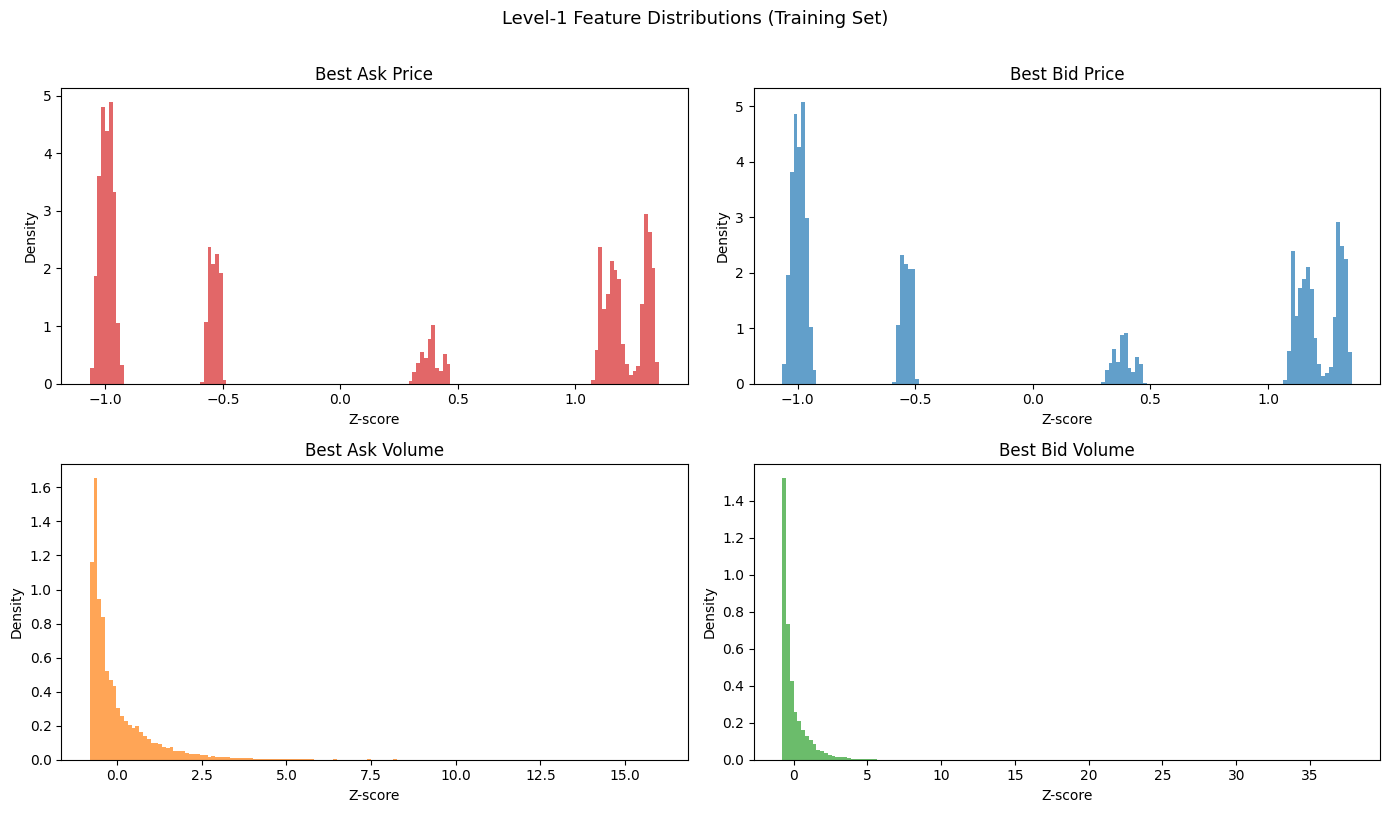

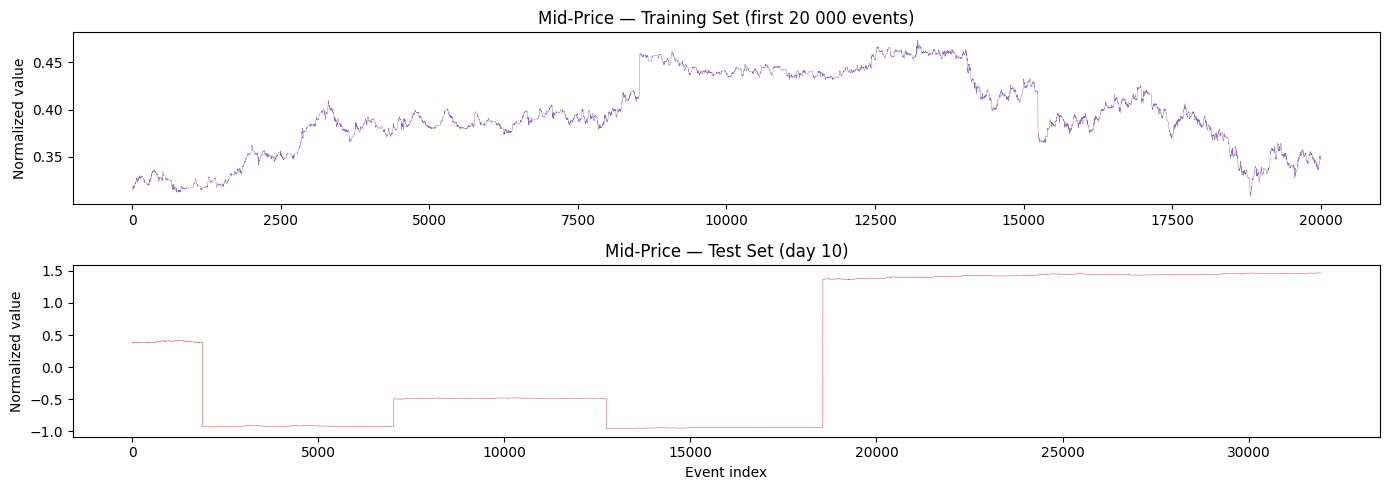

In [8]:
# Level-1 feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, idx, title, color in [
    (axes[0, 0], 0, "Best Ask Price", "tab:red"),
    (axes[0, 1], 2, "Best Bid Price", "tab:blue"),
    (axes[1, 0], 1, "Best Ask Volume", "tab:orange"),
    (axes[1, 1], 3, "Best Bid Volume", "tab:green"),
]:
    ax.hist(X_train[:, idx], bins=150, alpha=0.7, color=color, density=True)
    ax.set_title(title)
    ax.set_xlabel("Z-score")
    ax.set_ylabel("Density")

plt.suptitle("Level-1 Feature Distributions (Training Set)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Mid-price time series: train vs test
fig, axes = plt.subplots(2, 1, figsize=(14, 5))

axes[0].plot(mid_train[:20_000], linewidth=0.3, color="tab:purple")
axes[0].set_title("Mid-Price — Training Set (first 20 000 events)")
axes[0].set_ylabel("Normalized value")

axes[1].plot(mid_test, linewidth=0.3, color="tab:red")
axes[1].set_title("Mid-Price — Test Set (day 10)")
axes[1].set_ylabel("Normalized value")
axes[1].set_xlabel("Event index")

plt.tight_layout()
plt.show()

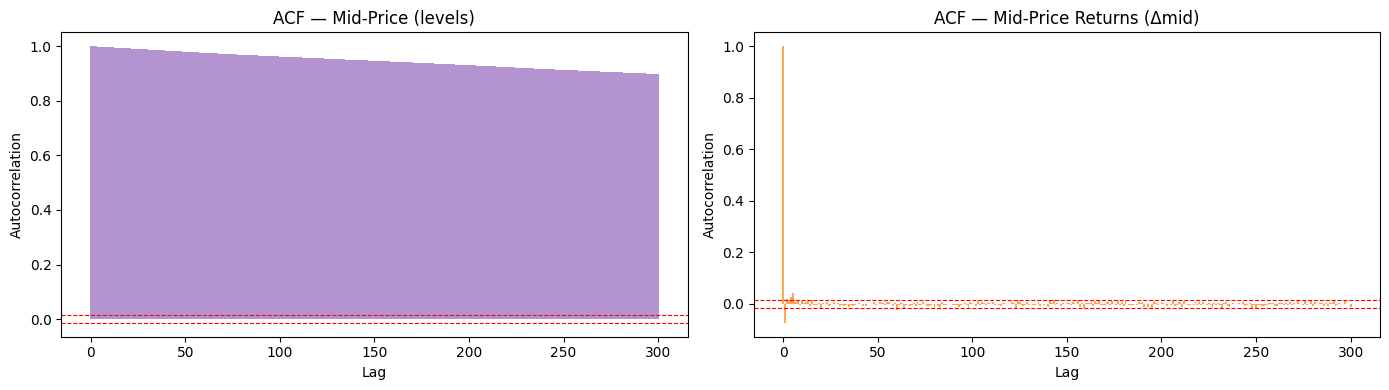

Mid-price levels show near-unit autocorrelation at all displayed lags,
confirming strong temporal dependence — a random train/test shuffle
would massively leak this structure into the test set.

Mid-price returns show fast-decaying ACF — price *changes* are closer
to stationary, which is why the reward signal (based on Δmid) is
well-behaved for reinforcement learning.


In [9]:
def compute_acf(x, max_lag=300):
    """Autocorrelation function via numpy fast-path."""
    n = len(x)
    x = x - x.mean()
    c0 = np.dot(x, x) / n
    acf_vals = np.empty(max_lag + 1)
    acf_vals[0] = 1.0
    for h in range(1, max_lag + 1):
        acf_vals[h] = np.dot(x[: n - h], x[h:]) / (n * c0)
    return acf_vals

max_lag = 300
n_sub = 20_000

acf_levels  = compute_acf(mid_train[:n_sub], max_lag)
acf_returns = compute_acf(np.diff(mid_train[: n_sub + 1]), max_lag)
ci = 1.96 / np.sqrt(n_sub)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(max_lag + 1), acf_levels, width=1.0, color="tab:purple", alpha=0.7)
axes[0].axhline(ci, color="red", ls="--", lw=0.8)
axes[0].axhline(-ci, color="red", ls="--", lw=0.8)
axes[0].set_title("ACF — Mid-Price (levels)")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelation")

axes[1].bar(range(max_lag + 1), acf_returns, width=1.0, color="tab:orange", alpha=0.7)
axes[1].axhline(ci, color="red", ls="--", lw=0.8)
axes[1].axhline(-ci, color="red", ls="--", lw=0.8)
axes[1].set_title("ACF — Mid-Price Returns (Δmid)")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

print("Mid-price levels show near-unit autocorrelation at all displayed lags,")
print("confirming strong temporal dependence — a random train/test shuffle")
print("would massively leak this structure into the test set.\n")
print("Mid-price returns show fast-decaying ACF — price *changes* are closer")
print("to stationary, which is why the reward signal (based on Δmid) is")
print("well-behaved for reinforcement learning.")

## 7. Define the Trading Environment

We formalize LOB trading as a **Markov Decision Process** and implement it as a [Gymnasium](https://gymnasium.farama.org/) environment in `lob_trading_env.py`.

### State space

At each decision step $t$, the agent observes:

$$
s_t = \bigl(\underbrace{\mathbf{X}_{t-W+1:t}}_{\in\,\mathbb{R}^{W \times 40}},\; q_{t-1}\bigr)
$$

where $W = 100$ is the lookback window (following DeepLOB) and $q_{t-1} \in \{-1, 0, +1\}$ is the current inventory position.

### Action space

$$
a_t \in \{0, 1, 2\} \quad\longleftrightarrow\quad q_t \in \{-1,\; 0,\; +1\}
$$

The agent directly selects its desired position: **short** ($-1$), **flat** ($0$), or **long** ($+1$).

### Reward function

$$
r_t \;=\; q_t \,\cdot\, \underbrace{(m_{t+1} - m_t)}_{\Delta\text{mid-price}} \;-\; c \,\cdot\, \underbrace{|q_t - q_{t-1}|}_{\text{position change}}
$$

- The first term is the **PnL**: holding position $q_t$ while the mid-price moves from $m_t$ to $m_{t+1}$.
- The second term penalises **transaction costs** proportional to the change in position, with cost parameter $c$.

### Episode structure

Each episode walks through a contiguous segment of LOB data. The agent starts flat ($q_0 = 0$) and takes one action per event. A fixed `episode_length` can be set to sample random windows, or the full dataset can be traversed as a single episode.

Observation keys : ['lob_window', 'position']
LOB window shape : (100, 40)
Initial position : 0
Initial mid-price: -0.9955

Episode length     : 5,000 steps
Total reward (PnL) : 0.004421
Mean step reward   : 0.00000088
Std step reward    : 0.00025531


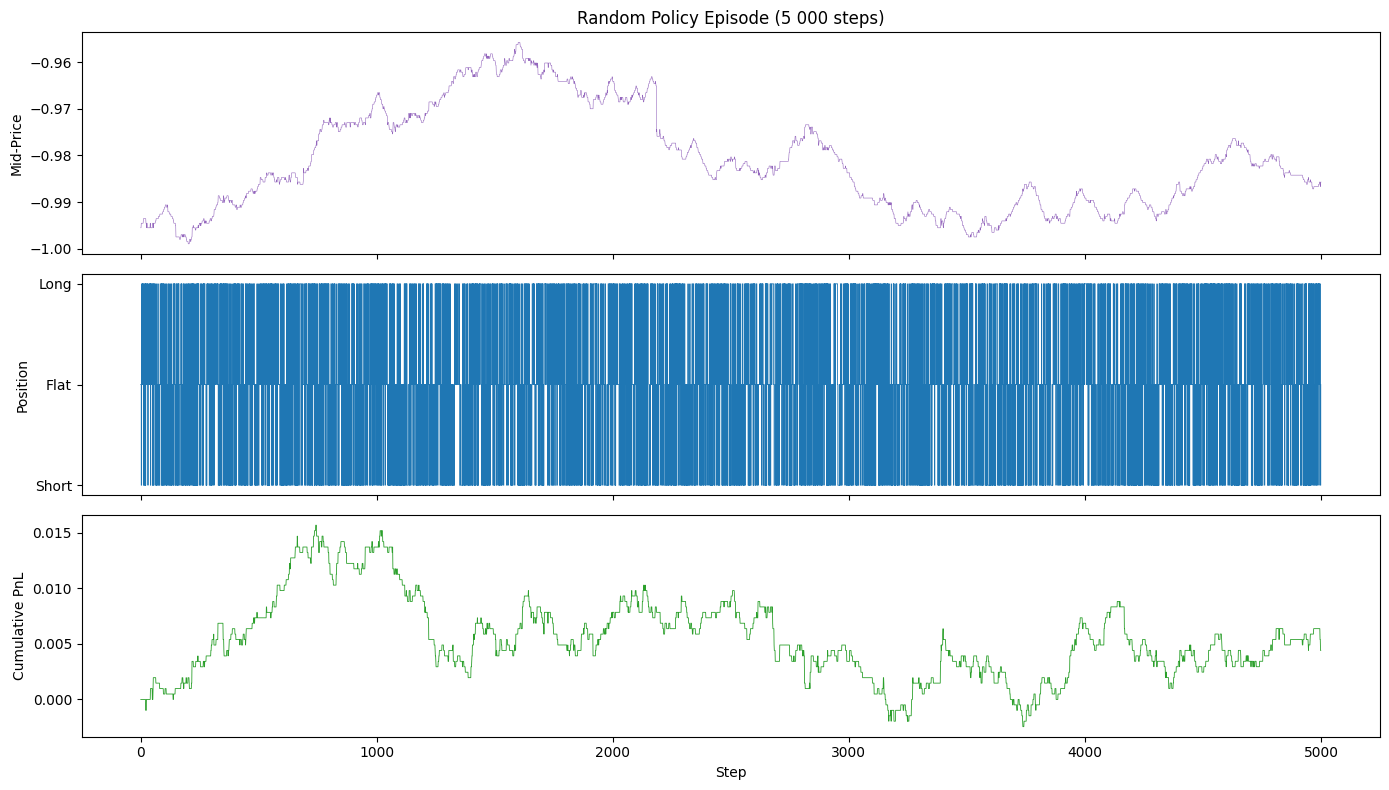

In [12]:
from src.env.lob_trading_env import LOBTradingEnv

env = LOBTradingEnv(X_train, window_size=100, transaction_cost=0.0, episode_length=5000)

obs, info = env.reset(seed=42)
print(f"Observation keys : {list(obs.keys())}")
print(f"LOB window shape : {obs['lob_window'].shape}")
print(f"Initial position : {obs['position'].item():.0f}")
print(f"Initial mid-price: {info['mid_price']:.4f}\n")

# Random policy rollout
rewards, positions, mids = [], [], [info["mid_price"]]
done = False
while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)
    positions.append(info["position"])
    mids.append(info["mid_price"])
    done = terminated or truncated

rewards = np.array(rewards)
print(f"Episode length     : {len(rewards):,} steps")
print(f"Total reward (PnL) : {rewards.sum():.6f}")
print(f"Mean step reward   : {rewards.mean():.8f}")
print(f"Std step reward    : {rewards.std():.8f}")

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(mids, linewidth=0.4, color="tab:purple")
axes[0].set_ylabel("Mid-Price")
axes[0].set_title("Random Policy Episode (5 000 steps)")

axes[1].step(range(len(positions)), positions, linewidth=0.6, color="tab:blue", where="post")
axes[1].set_ylabel("Position")
axes[1].set_yticks([-1, 0, 1])
axes[1].set_yticklabels(["Short", "Flat", "Long"])

axes[2].plot(np.cumsum(rewards), linewidth=0.6, color="tab:green")
axes[2].set_ylabel("Cumulative PnL")
axes[2].set_xlabel("Step")

plt.tight_layout()
plt.show()

## 8. Generate Offline Trajectories

In offline RL, we don't interact with the environment during training. We first collect a **fixed dataset** of trajectories, then train on it. The Decision Transformer (Chen et al., 2021) needs trajectories with the **return-to-go**:

$$\hat{R}_t = \sum_{t'=t}^{T} r_{t'}$$

### Why we need many diverse policies

The DT learns to condition on the desired return. So it must see **trajectories of very different quality** — from excellent to poor. We use **6 policies**:

| Policy | Logic | Expected return |
|--------|-------|-----------------|
| **Oracle** | Looks at the *actual* next mid-price move $\Delta m = m_{t+1} - m_t$. Impossible in real life, but gives the best possible trajectories. | Best |
| **Label-momentum** | Follows FI-2010 labels at horizon $k=50$: buy if label = up, sell if label = down. | Good |
| **Imbalance** | If bid vol > ask vol at level 1 $\to$ go long, opposite $\to$ short. | Decent |
| **Momentum** | If mid-price went up over last 20 steps $\to$ go long, if down $\to$ short. | Decent |
| **Mean-reversion** | Opposite of label-momentum. Intentionally bad, for contrast. | Poor |
| **Random** | Uniform random $\to$ baseline. | Baseline |

This strategy is inspired by the approach in `main_v2.ipynb` — mixing an oracle policy for strong signal with weaker policies for diversity.

In [13]:
STATE_DIM = 41  # 40 LOB features (last snapshot) + 1 position


def flatten_state(obs):
    """Last LOB snapshot + current position -> flat vector of dim 41."""
    return np.concatenate([obs["lob_window"][-1], obs["position"]])


def rollout(env, policy_fn, seed=None, labels=None):
    """Run one full episode. Pass labels for policies that need them."""
    obs, info = env.reset(seed=seed)
    states, actions, rewards = [], [], []
    done = False
    while not done:
        action = policy_fn(
            lob_window=obs["lob_window"],
            pos=obs["position"][0],
            env=env,
            labels=labels,
        )
        states.append(flatten_state(obs))
        actions.append(action)
        obs, reward, terminated, truncated, info = env.step(action)
        rewards.append(reward)
        done = terminated or truncated
    return {
        "states":  np.array(states, dtype=np.float32),
        "actions": np.array(actions, dtype=np.int64),
        "rewards": np.array(rewards, dtype=np.float32),
    }


# ── Policy 1: Random ──────────────────────────────────────────────
def random_policy(lob_window, pos, **kwargs):
    return np.random.randint(0, 3)


# ── Policy 2: Imbalance ───────────────────────────────────────────
# Compare z-scored bid vol vs ask vol at level 1.
# bid_vol > ask_vol -> more buy pressure -> go long
def imbalance_policy(lob_window, pos, **kwargs):
    ask_vol = lob_window[-1, 1]
    bid_vol = lob_window[-1, 3]
    diff = bid_vol - ask_vol
    if diff > 0.15:
        return 2   # long
    elif diff < -0.15:
        return 0   # short
    return 1       # flat


# ── Policy 3: Momentum (mid-price based) ──────────────────────────
# If mid-price went up over last 20 steps -> long
def momentum_policy(lob_window, pos, **kwargs):
    mid = (lob_window[:, 0] + lob_window[:, 2]) / 2.0
    delta = mid[-1] - mid[-20]
    if delta > 0.003:
        return 2   # long
    elif delta < -0.003:
        return 0   # short
    return 1       # flat


# ── Policy 4: Oracle (perfect foresight) ──────────────────────────
# Looks at the ACTUAL next mid-price move. This is cheating, but it
# gives the DT a strong signal for what "good" behaviour looks like.
def oracle_policy(lob_window, pos, env=None, **kwargs):
    t = env._current_step
    mid_now  = env.mid_prices[t]
    mid_next = env.mid_prices[t + 1]
    delta = mid_next - mid_now
    if delta > 0:
        return 2   # long
    elif delta < 0:
        return 0   # short
    return 1       # flat (no move -> stay flat)


# ── Policy 5: Label-momentum (FI-2010 labels, k=50) ──────────────
# Uses the pre-computed FI-2010 labels at horizon k=50 (column 3).
# Labels: 1=down, 2=stationary, 3=up
def label_momentum_policy(lob_window, pos, env=None, labels=None, **kwargs):
    t = env._current_step
    label = int(labels[t, 3])
    if label == 1:
        return 0   # short (price going down)
    elif label == 3:
        return 2   # long (price going up)
    return 1       # flat


# ── Policy 6: Mean-reversion (contrarian, opposite of label-mom) ──
# Intentionally mediocre: bet against the trend. Gives low-return
# trajectories for contrast.
def mean_reversion_policy(lob_window, pos, env=None, labels=None, **kwargs):
    t = env._current_step
    label = int(labels[t, 3])
    if label == 1:
        return 2   # long (contrarian: price going down -> buy)
    elif label == 3:
        return 0   # short (contrarian: price going up -> sell)
    return 1       # flat

### Collect trajectories and compute return-to-go

We run each of the 6 policies **100 times** on random 2000-step windows from the training data (total: 600 trajectories, ~1.2M transitions).

After each episode we compute the **return-to-go** by backward cumulative sum:

$$\hat{R}_t = r_t + \hat{R}_{t+1}, \qquad \hat{R}_T = r_T$$

This is the conditioning signal for the Decision Transformer: "I want this much future reward from here".

In [14]:
env_traj = LOBTradingEnv(X_train, window_size=100, transaction_cost=0.0, episode_length=2000)

policies = {
    "random":     random_policy,
    "imbalance":  imbalance_policy,
    "momentum":   momentum_policy,
    "oracle":     oracle_policy,
    "label_mom":  label_momentum_policy,
    "mean_rev":   mean_reversion_policy,
}
seed_offsets = {
    "random": 0, "imbalance": 10000, "momentum": 20000,
    "oracle": 30000, "label_mom": 40000, "mean_rev": 50000,
}

N_EPISODES = 1000
all_trajectories = []

np.random.seed(42)
for name, pfn in policies.items():
    ep_returns = []
    for i in range(N_EPISODES):
        traj = rollout(env_traj, pfn, seed=seed_offsets[name] + i, labels=y_train)

        # Return-to-go = backward cumulative sum of rewards
        R = traj["rewards"]
        rtg = np.zeros_like(R)
        rtg[-1] = R[-1]
        for t in range(len(R) - 2, -1, -1):
            rtg[t] = R[t] + rtg[t + 1]

        traj["returns_to_go"] = rtg
        traj["policy"] = name
        all_trajectories.append(traj)
        ep_returns.append(R.sum())

    print(f"{name:12s} | {N_EPISODES} episodes | "
          f"mean return = {np.mean(ep_returns):+.6f} | "
          f"std = {np.std(ep_returns):.6f} | best = {np.max(ep_returns):+.6f}")

total_transitions = sum(len(t["rewards"]) for t in all_trajectories)
print(f"\nTotal: {len(all_trajectories)} trajectories, {total_transitions:,} transitions")

random       | 1000 episodes | mean return = -0.002087 | std = 0.137423 | best = +2.065571
imbalance    | 1000 episodes | mean return = +0.067217 | std = 0.136993 | best = +2.147952
momentum     | 1000 episodes | mean return = +0.008552 | std = 0.019745 | best = +0.124611
oracle       | 1000 episodes | mean return = +0.373781 | std = 0.259145 | best = +2.504961
label_mom    | 1000 episodes | mean return = -0.100851 | std = 0.180561 | best = +1.986126
mean_rev     | 1000 episodes | mean return = +0.104617 | std = 0.188122 | best = +0.501675

Total: 6000 trajectories, 12,000,000 transitions


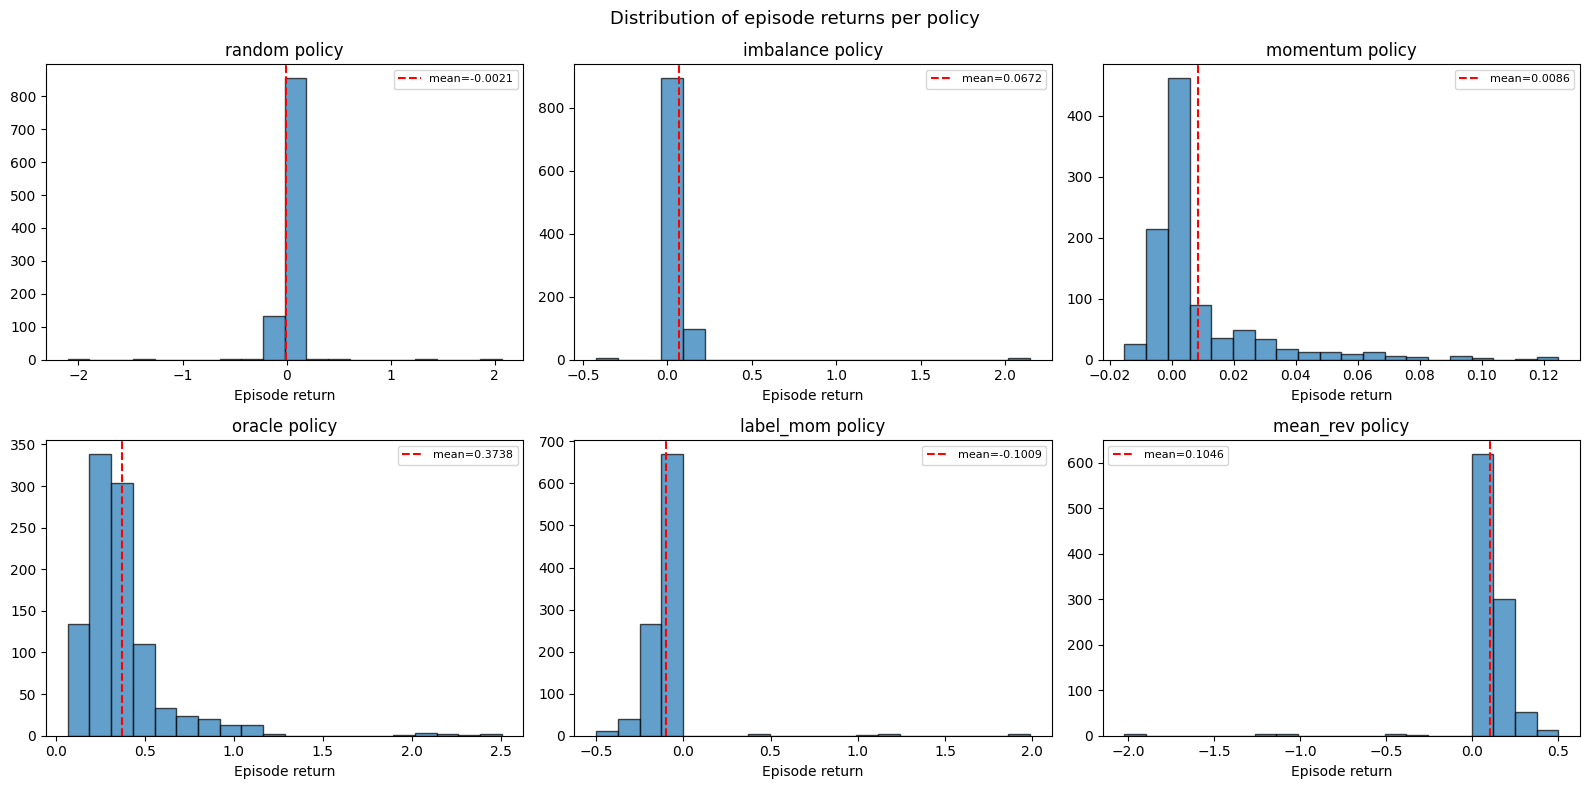

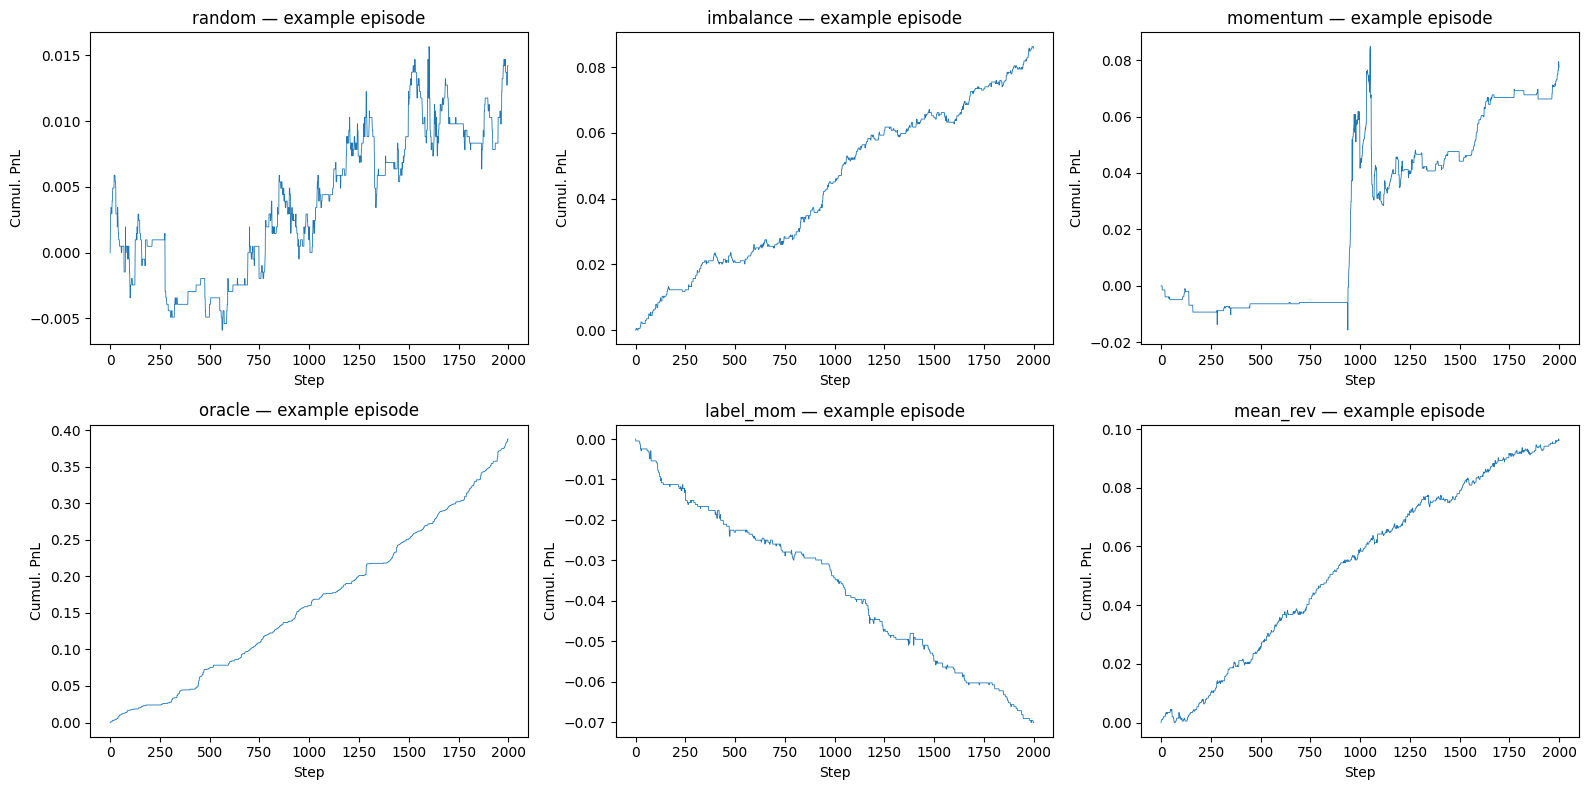

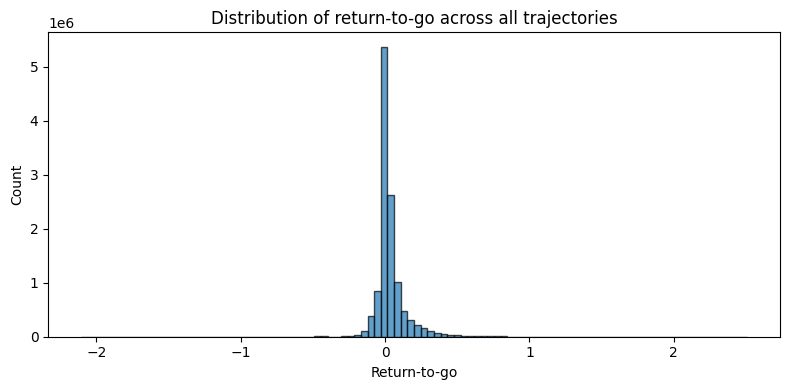

RTG range: [-2.1038, 2.5050]
RTG mean:  0.0373, std: 0.1440


In [15]:
# ── Distribution of returns per policy ──
n_policies = len(policies)
n_cols = 3
n_rows = (n_policies + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes_flat = axes.flatten()
for i, name in enumerate(policies.keys()):
    ax = axes_flat[i]
    rets = [t["rewards"].sum() for t in all_trajectories if t["policy"] == name]
    ax.hist(rets, bins=20, alpha=0.7, edgecolor="black")
    ax.set_title(f"{name} policy")
    ax.set_xlabel("Episode return")
    ax.axvline(np.mean(rets), color="red", linestyle="--", label=f"mean={np.mean(rets):.4f}")
    ax.legend(fontsize=8)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)
fig.suptitle("Distribution of episode returns per policy", fontsize=13)
plt.tight_layout()
plt.show()

# ── Example trajectory per policy ──
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes_flat = axes.flatten()
for i, name in enumerate(policies.keys()):
    ax = axes_flat[i]
    traj = [t for t in all_trajectories if t["policy"] == name][0]
    ax.plot(np.cumsum(traj["rewards"]), linewidth=0.6)
    ax.set_ylabel("Cumul. PnL")
    ax.set_xlabel("Step")
    ax.set_title(f"{name} — example episode")
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)
plt.tight_layout()
plt.show()

# ── Return-to-go distribution ──
all_rtg = np.concatenate([t["returns_to_go"] for t in all_trajectories])
plt.figure(figsize=(8, 4))
plt.hist(all_rtg, bins=100, alpha=0.7, edgecolor="black")
plt.xlabel("Return-to-go")
plt.ylabel("Count")
plt.title("Distribution of return-to-go across all trajectories")
plt.tight_layout()
plt.show()

print(f"RTG range: [{all_rtg.min():.4f}, {all_rtg.max():.4f}]")
print(f"RTG mean:  {all_rtg.mean():.4f}, std: {all_rtg.std():.4f}")

## 9. Build the Decision Transformer

The **Decision Transformer** (Chen et al., 2021 — `arXiv 2106.01345`) reformulates RL as **sequence modelling**. Instead of learning a value function $Q(s,a)$ or doing policy gradient, we train a **GPT-like model** to predict actions from past experience.

### The key idea

At test time, we tell the model "I want a total return of $\hat{R}$" and it outputs the actions to achieve it:

$$a_t = \text{DT}\!\bigl(\hat{R}_1, s_1, a_1, \;\hat{R}_2, s_2, a_2, \;\dots,\; \hat{R}_t, s_t\bigr)$$

The input is a sequence of **triplets** $(\hat{R}_t, s_t, a_t)$ processed with a **causal mask** (like GPT): each token only sees past tokens.

### Architecture overview

We build the model step by step in 3 classes:

1. `CausalSelfAttention` — masked multi-head attention mechanism
2. `TransformerBlock` — one GPT-2 block (attention + MLP + residual + LayerNorm)
3. `DecisionTransformer` — full model (embeddings + $N$ blocks + action prediction head)

### Step 1 — Causal Self-Attention

This is the core mechanism of the transformer. We project the input $\mathbf{X} \in \mathbb{R}^{T \times d}$ into queries, keys, and values:

$$\mathbf{Q} = \mathbf{X}\mathbf{W}_Q, \quad \mathbf{K} = \mathbf{X}\mathbf{W}_K, \quad \mathbf{V} = \mathbf{X}\mathbf{W}_V$$

Then we compute the attention with a **causal mask** so each token only sees the past:

$$\text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{softmax}\!\left(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d_k}} + \mathbf{M}\right)\mathbf{V}$$

where $\mathbf{M}$ is the mask: $M_{ij} = 0$ if $i \geq j$ (can attend), $-\infty$ if $i < j$ (future = blocked).

We split into $h$ heads, each of dimension $d_k = d/h$, so the model learns different attention patterns in parallel.

In [16]:
class CausalSelfAttention(nn.Module):
    """Multi-head causal (masked) self-attention."""

    def __init__(self, d_model, n_heads, max_seq_len, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

        mask = torch.tril(torch.ones(max_seq_len, max_seq_len))
        self.register_buffer("mask", mask.view(1, 1, max_seq_len, max_seq_len))

    def forward(self, x):
        B, T, C = x.shape

        qkv = self.qkv_proj(x).reshape(B, T, 3, self.n_heads, self.d_k)
        qkv = qkv.permute(2, 0, 3, 1, 4)           # (3, B, h, T, d_k)
        q, k, v = qkv.unbind(0)                      # each: (B, h, T, d_k)

        att = (q @ k.transpose(-2, -1)) / (self.d_k ** 0.5)    # (B, h, T, T)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = torch.softmax(att, dim=-1)
        att = self.attn_drop(att)

        out = (att @ v).transpose(1, 2).reshape(B, T, C)        # (B, T, d)
        return self.resid_drop(self.out_proj(out))

### Step 2 — Transformer Block (GPT-2 style, pre-norm)

One block = attention + feed-forward network, both with **residual connections** and **LayerNorm before** each sub-layer (this is the "pre-norm" variant used in GPT-2):

$$\mathbf{h} = \mathbf{x} + \text{CausalAttn}\!\bigl(\text{LayerNorm}(\mathbf{x})\bigr)$$

$$\text{out} = \mathbf{h} + \text{MLP}\!\bigl(\text{LayerNorm}(\mathbf{h})\bigr)$$

The MLP has two linear layers with GELU activation and expansion factor 4:

$$\text{MLP}(\mathbf{z}) = \mathbf{W}_2 \,\text{GELU}\!\bigl(\mathbf{W}_1 \mathbf{z} + \mathbf{b}_1\bigr) + \mathbf{b}_2, \quad \mathbf{W}_1 \in \mathbb{R}^{d \times 4d}$$

We stack $N$ of these blocks. More blocks = more capacity to learn complex sequence patterns.

In [17]:
class TransformerBlock(nn.Module):
    """One GPT-2 pre-norm block: LN -> Attn -> residual -> LN -> MLP -> residual."""

    def __init__(self, d_model, n_heads, max_seq_len, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, max_seq_len, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

### Step 3 — The Full Decision Transformer

Now we assemble everything. The model takes the last $K$ timesteps of $(\hat{R}_t, s_t, a_t)$ and predicts actions.

**Token embeddings.** Each modality gets its own projection into $\mathbb{R}^d$:

- State: $\mathbf{e}_s = \mathbf{W}_s \, s_t + \mathbf{b}_s$ — linear layer ($\mathbb{R}^{41} \to \mathbb{R}^{d}$)
- Action: $\mathbf{e}_a = \text{Embed}(a_t)$ — lookup table ($\{0,1,2\} \to \mathbb{R}^{d}$)
- Return-to-go: $\mathbf{e}_r = \mathbf{W}_r \, \hat{R}_t + \mathbf{b}_r$ — linear layer ($\mathbb{R}^1 \to \mathbb{R}^{d}$)

**Timestep embedding.** A learned vector $\mathbf{p}_t \in \mathbb{R}^d$ is added to all 3 tokens at timestep $t$, so the model knows **when** each event happens.

**Sequence interleaving.** Tokens are put in order:

$$\bigl[\mathbf{e}_{r,1},\; \mathbf{e}_{s,1},\; \mathbf{e}_{a,1},\; \mathbf{e}_{r,2},\; \mathbf{e}_{s,2},\; \mathbf{e}_{a,2},\; \dots\bigr] \quad \text{(total: } 3K \text{ tokens)}$$

**Action prediction.** After the transformer, we extract the output at **state positions** (indices $1, 4, 7, \dots$) and project to action logits:

$$\hat{a}_t = \arg\max\!\bigl(\mathbf{W}_a \, \mathbf{h}_{s_t} + \mathbf{b}_a\bigr)$$

The causal mask guarantees that $\mathbf{h}_{s_t}$ can see $(\hat{R}_t, s_t)$ and all previous triplets, but **not** $a_t$ itself — so the prediction is valid.

In [18]:
class DecisionTransformer(nn.Module):
    """
    Decision Transformer (Chen et al., 2021).
    GPT-style sequence model on (return-to-go, state, action) triplets.
    """

    def __init__(
        self,
        state_dim=41,
        act_dim=3,
        d_model=128,
        n_heads=4,
        n_layers=3,
        max_timestep=2048,
        context_len=20,
        dropout=0.1,
    ):
        super().__init__()
        self.d_model = d_model
        self.context_len = context_len

        self.embed_state = nn.Linear(state_dim, d_model)
        self.embed_action = nn.Embedding(act_dim, d_model)
        self.embed_rtg = nn.Linear(1, d_model)
        self.embed_timestep = nn.Embedding(max_timestep, d_model)

        self.ln = nn.LayerNorm(d_model)
        max_seq_len = 3 * context_len
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, max_seq_len, dropout)
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.action_head = nn.Linear(d_model, act_dim)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, states, actions, rtg, timesteps):
        """
        states:    (B, K, state_dim)   float
        actions:   (B, K)              int
        rtg:       (B, K, 1)           float
        timesteps: (B, K)              int
        Returns:   action_logits (B, K, act_dim)
        """
        B, K, _ = states.shape

        t_emb = self.embed_timestep(timesteps)
        s_tok = self.embed_state(states) + t_emb
        a_tok = self.embed_action(actions) + t_emb
        r_tok = self.embed_rtg(rtg) + t_emb

        # Interleave: [R_hat_1, s_1, a_1, R_hat_2, s_2, a_2, ...]
        seq = torch.zeros(B, 3 * K, self.d_model, device=states.device)
        seq[:, 0::3] = r_tok   # positions 0, 3, 6, ...
        seq[:, 1::3] = s_tok   # positions 1, 4, 7, ...
        seq[:, 2::3] = a_tok   # positions 2, 5, 8, ...

        seq = self.ln(seq)
        for block in self.blocks:
            seq = block(seq)
        seq = self.ln_f(seq)

        # Predict action from state-token positions
        h_states = seq[:, 1::3]                    # (B, K, d)
        action_logits = self.action_head(h_states)  # (B, K, act_dim)
        return action_logits

### Step 4 — Trajectory Dataset for Training

To train the DT, we build a PyTorch Dataset that extracts **sliding windows** of length $K$ from our offline trajectories:

$$\bigl(\hat{R}_{t:t+K},\; s_{t:t+K},\; a_{t:t+K},\; \text{timesteps}\bigr)$$

Each sample is one window. The training loss is **cross-entropy** on the predicted actions:

$$\mathcal{L} = -\frac{1}{K}\sum_{k=1}^{K} \log\, p_\theta\!\bigl(a_k \mid \hat{R}_{1:k}, s_{1:k}, a_{1:k-1}\bigr)$$

In [19]:
class TrajectoryDataset(torch.utils.data.Dataset):
    """
    Sliding-window dataset that pre-loads all trajectory data onto the target
    device (GPU) at construction time.  __getitem__ then becomes a pure GPU
    tensor slice — zero CPU-GPU transfer overhead during training.
    """

    def __init__(self, trajectories, context_len=20, dev=None):
        self.context_len = context_len
        self.dev = dev
        self._states  = []
        self._actions = []
        self._rtg     = []
        self.samples  = []

        for i, traj in enumerate(trajectories):
            T = len(traj["rewards"])
            s = torch.tensor(traj["states"],         dtype=torch.float32)
            a = torch.tensor(traj["actions"],         dtype=torch.long)
            r = torch.tensor(traj["returns_to_go"],   dtype=torch.float32).unsqueeze(-1)
            if dev is not None:
                s, a, r = s.to(dev), a.to(dev), r.to(dev)
            self._states.append(s)
            self._actions.append(a)
            self._rtg.append(r)
            for t in range(T - context_len):
                self.samples.append((i, t))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        i, t = self.samples[idx]
        K = self.context_len
        states    = self._states[i][t:t+K]
        actions   = self._actions[i][t:t+K]
        rtg       = self._rtg[i][t:t+K]
        timesteps = torch.arange(t, t + K, dtype=torch.long, device=self.dev)
        return states, actions, rtg, timesteps


# ── Build dataset and instantiate model ──────────────────────────
CONTEXT_LEN = 100

print("Pre-loading trajectories onto GPU…")
dataset = TrajectoryDataset(all_trajectories, context_len=CONTEXT_LEN, dev=device)
print(f"Dataset: {len(dataset):,} samples (sliding windows of K={CONTEXT_LEN})")

model = DecisionTransformer(
    state_dim=STATE_DIM,
    act_dim=3,
    d_model=128,
    n_heads=4,
    n_layers=3,
    max_timestep=2048,
    context_len=CONTEXT_LEN,
    dropout=0.1,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")

# Fuse kernels with torch.compile (PyTorch 2.0+, Linux/Mac only — Triton not available on Windows)
import sys
if hasattr(torch, "compile") and sys.platform != "win32":
    model = torch.compile(model)
    print("Model compiled with torch.compile ✓")
else:
    print("torch.compile skipped (not supported on Windows — running in eager mode)")

# ── Quick test: one forward pass ─────────────────────────────────
loader = torch.utils.data.DataLoader(dataset, batch_size=8, shuffle=True)
batch = next(iter(loader))
s, a, r, t = batch  # already on device

with torch.no_grad():
    logits = model(s, a, r, t)

print(f"\nForward pass OK!")
print(f"  Input:  states {tuple(s.shape)}, actions {tuple(a.shape)}, rtg {tuple(r.shape)}")
print(f"  Output: logits {tuple(logits.shape)}")
print(f"  Sample predictions (first 5 steps): {logits[0, :5].argmax(dim=-1).tolist()}")

Pre-loading trajectories onto GPU…
Dataset: 11,400,000 samples (sliding windows of K=100)
Model parameters: 863,875
Model compiled with torch.compile ✓


/home/calla/AI_projects/Decision-Transformer-LOB-Trading/.venv/lib/python3.13/site-packages/torch/_inductor/compile_fx.py:322: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(



Forward pass OK!
  Input:  states (8, 100, 41), actions (8, 100), rtg (8, 100, 1)
  Output: logits (8, 100, 3)
  Sample predictions (first 5 steps): [1, 1, 1, 1, 1]


## 10. Train the Decision Transformer

Ok so now we have our model and our dataset, we just need to train it. The idea is simple: we feed the model windows of (return-to-go, state, action) and we ask it to predict the correct action at each step. The loss is a classic **cross-entropy** on the action predictions.

We use **AdamW** with weight decay (like in the GPT papers) and a **cosine learning rate schedule** so the lr goes down smoothly during training. We also use gradient clipping to avoid explosions.

The training runs on GPU (CUDA or MPS) if you have one, otherwise it falls back to CPU but it will be slower obviously.

In [20]:
# -- Training hyperparameters --
EPOCHS     = 5
BATCH_SIZE = 1024   # RTX 5090 has 32 GB VRAM — push much larger batches
LR         = 1e-4
WD         = 1e-4
GRAD_CLIP  = 1.0

on_gpu = (device.type == "cuda")

# Data is already on GPU, so pin_memory must be False
train_loader = torch.utils.data.DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=False,
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS * len(train_loader))
loss_fn = nn.CrossEntropyLoss()

# Mixed-precision scaler (no-op when not on CUDA)
scaler = torch.amp.GradScaler(enabled=on_gpu)

print(f"Training on {device} | {len(dataset):,} samples | {EPOCHS} epochs | batch {BATCH_SIZE}")
print(f"Steps per epoch: {len(train_loader):,} | Total steps: {EPOCHS * len(train_loader):,}")
print(f"AMP mixed precision: {on_gpu} | torch.compile: {hasattr(torch, 'compile')}\n")

# -- Training loop --
history = {"loss": [], "acc": [], "lr": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss, epoch_correct, epoch_total = 0.0, 0, 0

    for step, (s, a, r, t) in enumerate(train_loader):
        # Tensors are already on GPU; non_blocking is a no-op but harmless
        s = s.to(device, non_blocking=True)
        a = a.to(device, non_blocking=True)
        r = r.to(device, non_blocking=True)
        t = t.to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, enabled=on_gpu):
            logits = model(s, a, r, t)               # (B, K, 3)
            loss   = loss_fn(logits.reshape(-1, 3), a.reshape(-1))

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        # track stats
        epoch_loss    += loss.item() * a.shape[0]
        epoch_correct += (logits.argmax(-1) == a).sum().item()
        epoch_total   += a.numel()

        if (step + 1) % 2000 == 0:
            print(f"  epoch {epoch} | step {step+1}/{len(train_loader)} | "
                  f"loss {loss.item():.4f} | lr {scheduler.get_last_lr()[0]:.2e}")

    avg_loss = epoch_loss / len(dataset)
    avg_acc  = epoch_correct / epoch_total
    history["loss"].append(avg_loss)
    history["acc"].append(avg_acc)
    history["lr"].append(scheduler.get_last_lr()[0])

    print(f"Epoch {epoch}/{EPOCHS} => loss: {avg_loss:.4f} | acc: {avg_acc:.3%} | lr: {history['lr'][-1]:.2e}")

print("\nTraining done.")

Training on cuda | 11,400,000 samples | 5 epochs | batch 1024
Steps per epoch: 11,133 | Total steps: 55,665
AMP mixed precision: True | torch.compile: True

  epoch 1 | step 2000/11133 | loss 0.5497 | lr 9.97e-05
  epoch 1 | step 4000/11133 | loss 0.5245 | lr 9.87e-05
  epoch 1 | step 6000/11133 | loss 0.5145 | lr 9.72e-05
  epoch 1 | step 8000/11133 | loss 0.5161 | lr 9.50e-05
  epoch 1 | step 10000/11133 | loss 0.5311 | lr 9.22e-05
Epoch 1/5 => loss: 0.5445 | acc: 77.166% | lr: 9.05e-05
  epoch 2 | step 2000/11133 | loss 0.5204 | lr 8.69e-05
  epoch 2 | step 4000/11133 | loss 0.4983 | lr 8.28e-05
  epoch 2 | step 6000/11133 | loss 0.4965 | lr 7.84e-05
  epoch 2 | step 8000/11133 | loss 0.4893 | lr 7.36e-05
  epoch 2 | step 10000/11133 | loss 0.5105 | lr 6.85e-05
Epoch 2/5 => loss: 0.5058 | acc: 78.131% | lr: 6.55e-05
  epoch 3 | step 2000/11133 | loss 0.4842 | lr 6.00e-05
  epoch 3 | step 4000/11133 | loss 0.4977 | lr 5.44e-05
  epoch 3 | step 6000/11133 | loss 0.4848 | lr 4.88e-05
 

In [21]:
# -- Save model weights --
WEIGHTS_PATH = Path("dt_lob_weights.pt")
torch.save(model.state_dict(), WEIGHTS_PATH)
print(f"Model weights saved to {WEIGHTS_PATH.resolve()}")

Model weights saved to /home/calla/AI_projects/Decision-Transformer-LOB-Trading/dt_lob_weights.pt


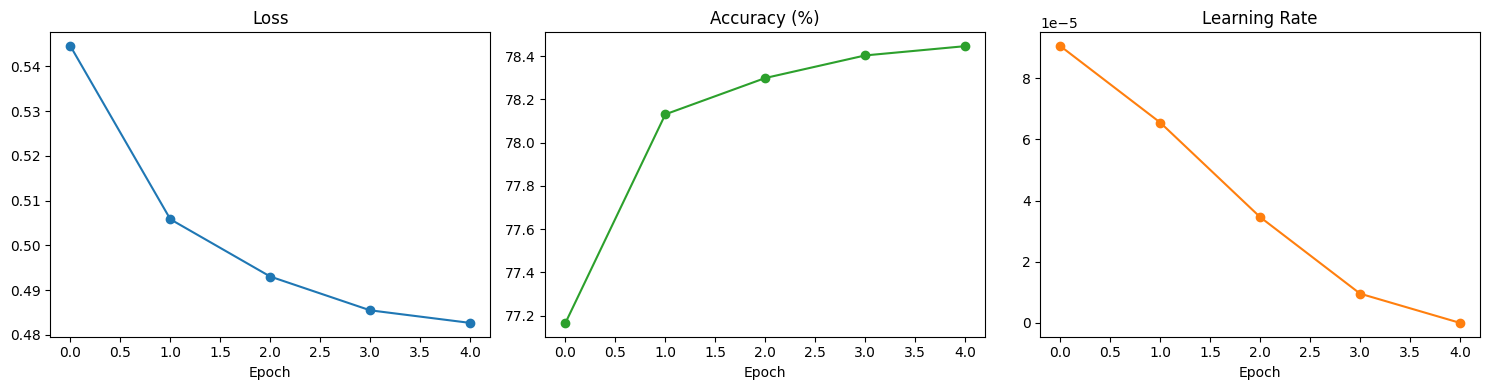

In [22]:
# -- Training curves --
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["loss"], "o-")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")

axes[1].plot([a * 100 for a in history["acc"]], "o-", color="tab:green")
axes[1].set_title("Accuracy (%)")
axes[1].set_xlabel("Epoch")

axes[2].plot(history["lr"], "o-", color="tab:orange")
axes[2].set_title("Learning Rate")
axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

### Load pre-trained weights (skip training)

If you have already trained the model and saved the weights, run this cell **instead of** the training cell above. It re-creates the model with the same architecture and loads the saved `state_dict`.

In [23]:
_weights = "dt_lob_weights.pt"
for _p in (Path(_weights), Path("Decision-Transformer-LOB-Trading") / _weights):
    if _p.is_file():
        WEIGHTS_PATH = _p.resolve()
        break
else:
    raise FileNotFoundError(
        f"Missing {_weights}. Tried ./{_weights} and Decision-Transformer-LOB-Trading/{_weights} (cwd={Path.cwd()})"
    )

import zipfile

try:
    with zipfile.ZipFile(WEIGHTS_PATH, "r") as _zf:
        _names = _zf.namelist()
except zipfile.BadZipFile:
    pass  # legacy pickle-only .pt
else:
    _has_blobs = any(
        "/data/" in n and n.rsplit("/", 1)[-1].isdigit() for n in _names
    )
    if _names and not _has_blobs:
        raise RuntimeError(
            f"{WEIGHTS_PATH} is incomplete (zip has no tensor storages under .../data/0, ...). "
            "Re-run training and the save cell — often caused by interrupted save or sync."
        )

model = DecisionTransformer(
    state_dim=STATE_DIM,
    act_dim=3,
    d_model=128,
    n_heads=4,
    n_layers=3,
    max_timestep=2048,
    context_len=CONTEXT_LEN,
    dropout=0.1,
).to(device)

model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device, weights_only=True))
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"Loaded weights from {WEIGHTS_PATH.resolve()}")
print(f"Model parameters: {n_params:,} | Device: {device}")

RuntimeError: Error(s) in loading state_dict for DecisionTransformer:
	Missing key(s) in state_dict: "embed_state.weight", "embed_state.bias", "embed_action.weight", "embed_rtg.weight", "embed_rtg.bias", "embed_timestep.weight", "ln.weight", "ln.bias", "blocks.0.ln1.weight", "blocks.0.ln1.bias", "blocks.0.attn.mask", "blocks.0.attn.qkv_proj.weight", "blocks.0.attn.qkv_proj.bias", "blocks.0.attn.out_proj.weight", "blocks.0.attn.out_proj.bias", "blocks.0.ln2.weight", "blocks.0.ln2.bias", "blocks.0.mlp.0.weight", "blocks.0.mlp.0.bias", "blocks.0.mlp.2.weight", "blocks.0.mlp.2.bias", "blocks.1.ln1.weight", "blocks.1.ln1.bias", "blocks.1.attn.mask", "blocks.1.attn.qkv_proj.weight", "blocks.1.attn.qkv_proj.bias", "blocks.1.attn.out_proj.weight", "blocks.1.attn.out_proj.bias", "blocks.1.ln2.weight", "blocks.1.ln2.bias", "blocks.1.mlp.0.weight", "blocks.1.mlp.0.bias", "blocks.1.mlp.2.weight", "blocks.1.mlp.2.bias", "blocks.2.ln1.weight", "blocks.2.ln1.bias", "blocks.2.attn.mask", "blocks.2.att

## 11. Evaluate & Backtest

Now we test if the model actually learned something useful. The idea is to deploy the DT on the **test set** (day 10 which it has never seen) and see how it trades.

The cool thing about the Decision Transformer is that we can **condition it on a target return**. So if we ask for a high return-to-go, the model should try to produce actions that lead to good performance. We test with different target returns to see the effect.

We compare the DT agent against the baseline policies we used to generate the training data (random, imbalance, momentum, etc). We look at:
- **Cumulative PnL** over time
- **Sharpe ratio** (return divided by volatility, basically how good is the risk/reward)
- **Action distribution** (does the model actually use all 3 actions or just spam one?)

### How the DT rollout works

At each step we feed the model the last $K$ steps of (return-to-go, state, action) and it predicts the next action. Then we execute that action in the environment and update the return-to-go by subtracting the reward we just got. Its like an autoregressive loop but for RL.

In [24]:
@torch.no_grad()
def dt_rollout(model, env, target_return, context_len=20, device="cpu"):
    """Run one episode with the Decision Transformer in autoregressive mode."""
    model.eval()
    obs, info = env.reset(seed=0)

    # buffers for the context window
    states  = [flatten_state(obs)]
    actions = [1]  # start flat
    rtg     = [target_return]

    rewards_all, positions_all, mids_all = [], [], [info["mid_price"]]
    done = False

    while not done:
        # take last K steps (or pad if we dont have enough yet)
        K = context_len
        T = len(states)
        start = max(0, T - K)

        s = torch.tensor(states[start:T],  dtype=torch.float32).unsqueeze(0).to(device)
        a = torch.tensor(actions[start:T],  dtype=torch.long).unsqueeze(0).to(device)
        r = torch.tensor(rtg[start:T],      dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
        # Training uses arange(t, t+K) within short episodes (< max_timestep). Full-day
        # rollouts exceed embed_timestep (index >= max_timestep) and trigger CUDA asserts.
        t_max = model.embed_timestep.num_embeddings - 1
        t = torch.arange(start, T, dtype=torch.long).clamp(max=t_max).unsqueeze(0).to(device)

        # pad on the left if sequence is shorter than K
        if s.shape[1] < K:
            pad = K - s.shape[1]
            s = torch.nn.functional.pad(s, (0, 0, pad, 0))
            a = torch.nn.functional.pad(a, (pad, 0), value=1)
            r = torch.nn.functional.pad(r, (0, 0, pad, 0))
            t = torch.nn.functional.pad(t, (pad, 0))

        logits = model(s, a, r, t)
        action = logits[0, -1].argmax().item()

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        states.append(flatten_state(obs))
        actions.append(action)
        # update return-to-go: subtract reward we got
        rtg.append(rtg[-1] - reward)

        rewards_all.append(reward)
        positions_all.append(info["position"])
        mids_all.append(info["mid_price"])

    return {
        "rewards":   np.array(rewards_all),
        "positions": np.array(positions_all),
        "mids":      np.array(mids_all),
    }

### Run the backtest on the test set

We create a test environment on day 10 data and run all the agents. For the DT we try several target returns to see how conditioning affects the behaviour. We also run the simple baselines for comparison.

In [25]:
# -- Test environment (full day 10, no transaction cost) --
env_test = LOBTradingEnv(X_test, window_size=100, transaction_cost=0.0, episode_length=None)

# -- DT rollouts with different target returns --
# we pick target returns based on what we observed during training
target_returns = [0.0, 0.05, 0.1, 0.2, 0.5]

dt_results = {}
for tr in target_returns:
    res = dt_rollout(model, env_test, target_return=tr, context_len=CONTEXT_LEN, device=device)
    dt_results[f"DT (R={tr})"] = res
    pnl = res["rewards"].sum()
    print(f"DT target_return={tr:<5} => PnL: {pnl:+.6f} | steps: {len(res['rewards'])}")

# -- Baseline rollouts on test set --
baseline_results = {}
baseline_policies = {
    "Random":     random_policy,
    "Imbalance":  imbalance_policy,
    "Momentum":   momentum_policy,
    "Oracle":     oracle_policy,
}

for name, pfn in baseline_policies.items():
    traj = rollout(env_test, pfn, seed=0, labels=y_test)
    baseline_results[name] = {
        "rewards": traj["rewards"],
        "positions": np.array([LOBTradingEnv.action_to_position(a) for a in traj["actions"]]),
    }
    pnl = traj["rewards"].sum()
    print(f"{name:<12} => PnL: {pnl:+.6f} | steps: {len(traj['rewards'])}")

/tmp/ipykernel_85167/4011987809.py:21: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  s = torch.tensor(states[start:T],  dtype=torch.float32).unsqueeze(0).to(device)


DT target_return=0.0   => PnL: +1.212264 | steps: 31836
DT target_return=0.05  => PnL: +1.213244 | steps: 31836
DT target_return=0.1   => PnL: +1.213244 | steps: 31836
DT target_return=0.2   => PnL: +1.210301 | steps: 31836
DT target_return=0.5   => PnL: +1.209318 | steps: 31836
Random       => PnL: -2.756007 | steps: 31836
Imbalance    => PnL: +3.088457 | steps: 31836
Momentum     => PnL: -0.011766 | steps: 31836
Oracle       => PnL: +9.240404 | steps: 31836


### Performance metrics

We compute total PnL, Sharpe ratio, max drawdown, and the percentage of time spent in each position.

In [26]:
def compute_metrics(rewards):
    """Compute PnL, Sharpe, and max drawdown from a reward array."""
    cum_pnl = np.cumsum(rewards)
    total_pnl = rewards.sum()
    sharpe = rewards.mean() / (rewards.std() + 1e-8) * np.sqrt(252 * 390)  # annualized (rough)
    running_max = np.maximum.accumulate(cum_pnl)
    drawdown = running_max - cum_pnl
    max_dd = drawdown.max()
    return {"PnL": total_pnl, "Sharpe": sharpe, "MaxDD": max_dd}


# -- Build comparison table --
rows = []

for name, res in dt_results.items():
    m = compute_metrics(res["rewards"])
    rows.append({"Agent": name, **m})

for name, res in baseline_results.items():
    m = compute_metrics(res["rewards"])
    rows.append({"Agent": name, **m})

df_metrics = pd.DataFrame(rows).set_index("Agent")
df_metrics = df_metrics.sort_values("PnL", ascending=False)
print(df_metrics.to_string(float_format=lambda x: f"{x:+.6f}" if abs(x) < 100 else f"{x:+.2f}"))

                  PnL    Sharpe     MaxDD
Agent                                    
Oracle      +9.240404 +5.957665 +0.000000
Imbalance   +3.088457 +2.274247 +0.476669
DT (R=0.05) +1.213244 +1.453985 +0.542394
DT (R=0.1)  +1.213244 +1.453985 +0.542394
DT (R=0.0)  +1.212264 +1.452811 +0.542394
DT (R=0.2)  +1.210301 +1.450457 +0.544356
DT (R=0.5)  +1.209318 +1.449279 +0.543863
Momentum    -0.011766 -0.699629 +0.038743
Random      -2.756007 -2.071189 +2.794747


### Cumulative PnL comparison

Here we plot all the agents together. The oracle is the best, it can see the future. The interesting question is whether the DT can do better than the simple heuristics.

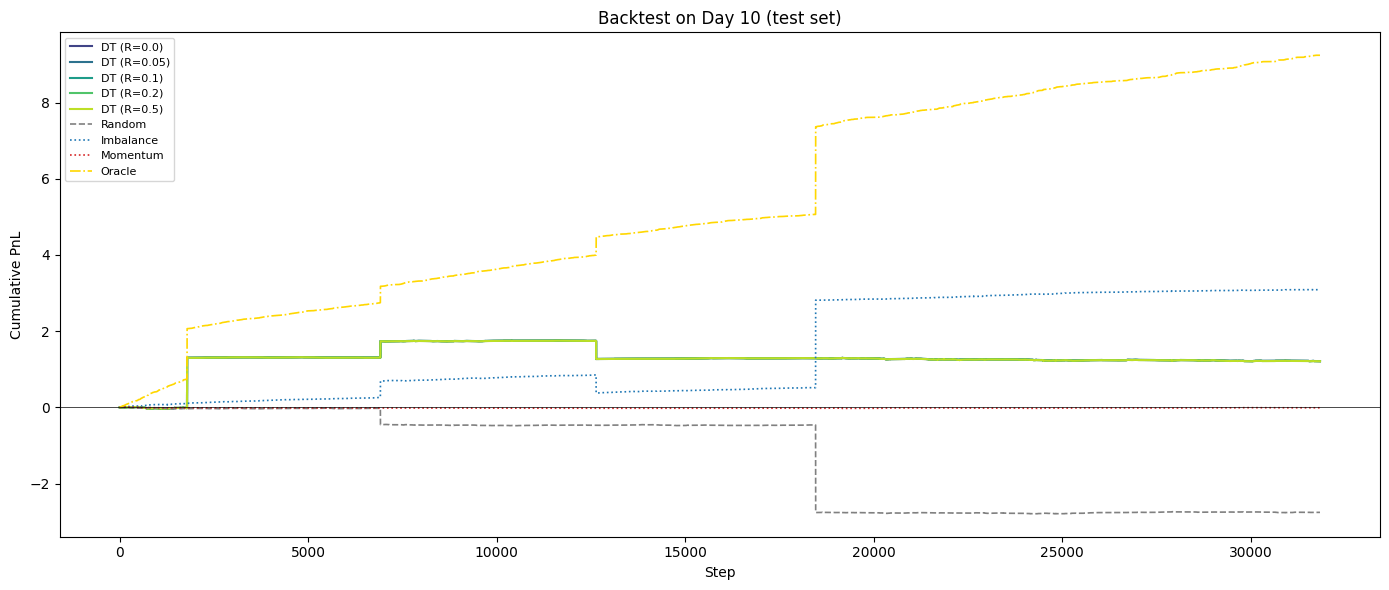

In [27]:
# -- Cumulative PnL plot --
fig, ax = plt.subplots(figsize=(14, 6))

# plot DT variants
cmap = plt.cm.viridis(np.linspace(0.2, 0.9, len(dt_results)))
for (name, res), color in zip(dt_results.items(), cmap):
    ax.plot(np.cumsum(res["rewards"]), label=name, linewidth=1.5, color=color)

# plot baselines
style = {"Random": ("grey", "--"), "Imbalance": ("tab:blue", ":"),
         "Momentum": ("tab:red", ":"), "Oracle": ("gold", "-.")}
for name, res in baseline_results.items():
    c, ls = style[name]
    ax.plot(np.cumsum(res["rewards"]), label=name, linewidth=1.2, color=c, linestyle=ls)

ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Step")
ax.set_ylabel("Cumulative PnL")
ax.set_title("Backtest on Day 10 (test set)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### Action distribution and position over time

We want to check that the DT is not just always predicting the same action . We also plot the position over time for the best DT variant to see if it actually changes its mind based on market conditions.

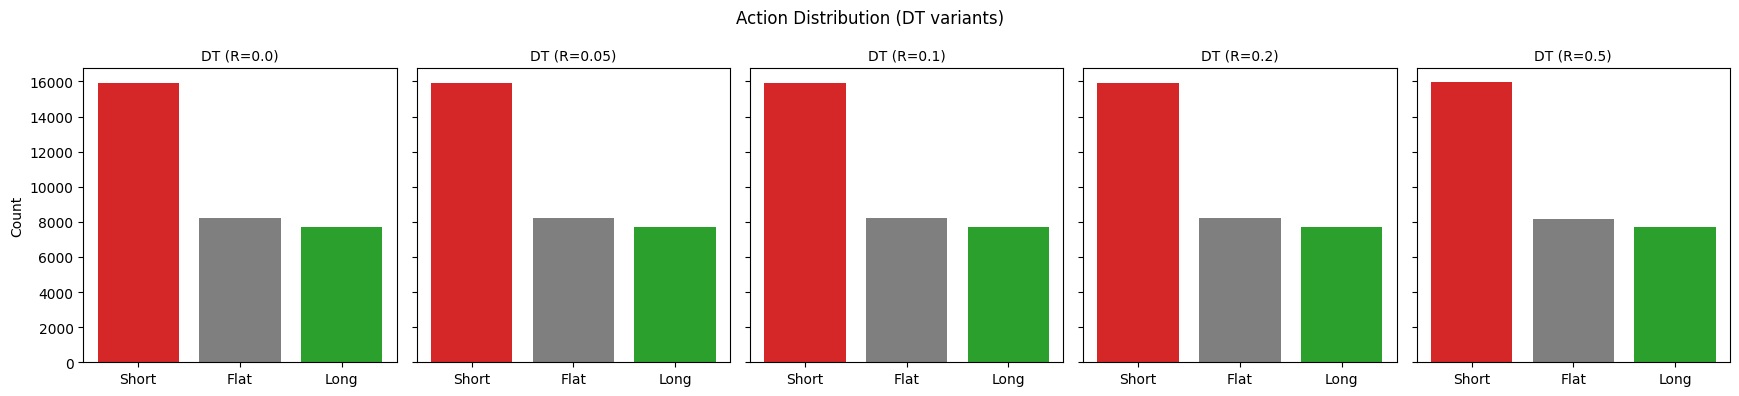

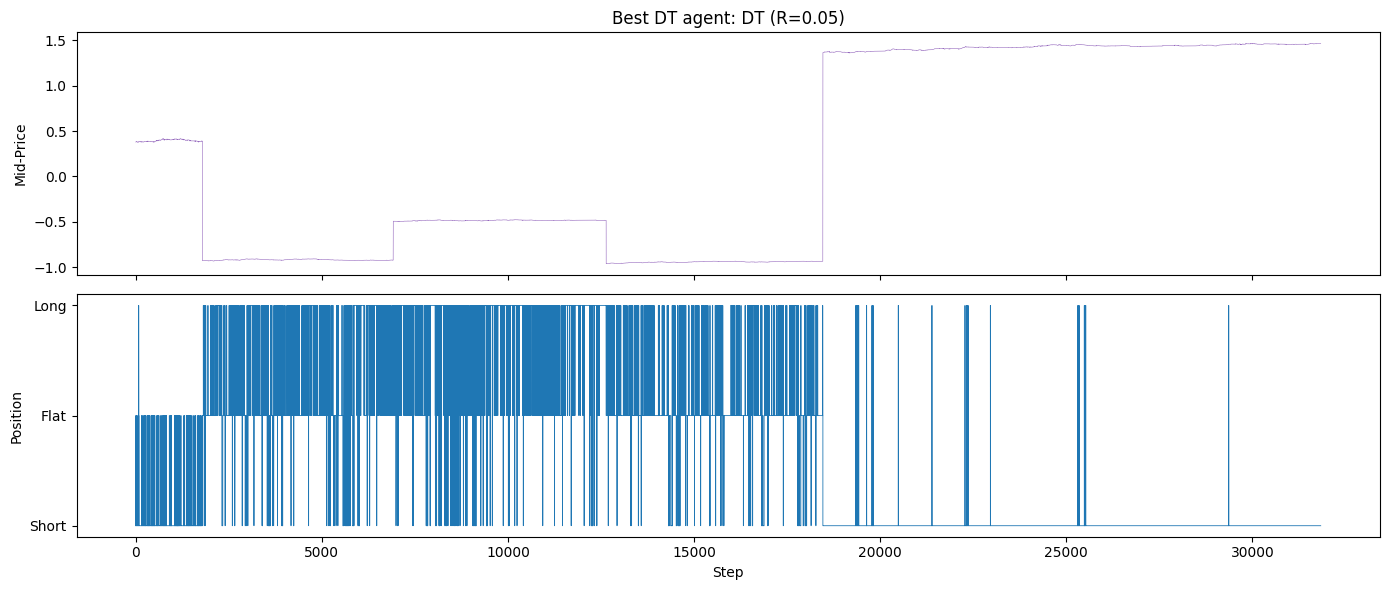

In [28]:
# -- Action distribution for each DT target return --
fig, axes = plt.subplots(1, len(dt_results), figsize=(3.5 * len(dt_results), 4), sharey=True)
action_labels = ["Short", "Flat", "Long"]

for ax, (name, res) in zip(axes, dt_results.items()):
    # positions are in {-1, 0, 1}, actions are pos+1 = {0, 1, 2}
    pos = res["positions"]
    counts = [(pos == -1).sum(), (pos == 0).sum(), (pos == 1).sum()]
    ax.bar(action_labels, counts, color=["tab:red", "tab:grey", "tab:green"])
    ax.set_title(name, fontsize=10)
    ax.set_ylabel("Count" if ax == axes[0] else "")

fig.suptitle("Action Distribution (DT variants)", fontsize=12)
plt.tight_layout()
plt.show()

# -- Best DT: position over time vs mid-price --
best_dt_name = max(dt_results, key=lambda k: dt_results[k]["rewards"].sum())
best_res = dt_results[best_dt_name]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(best_res["mids"], linewidth=0.4, color="tab:purple")
axes[0].set_ylabel("Mid-Price")
axes[0].set_title(f"Best DT agent: {best_dt_name}")

axes[1].step(range(len(best_res["positions"])), best_res["positions"],
             linewidth=0.6, color="tab:blue", where="post")
axes[1].set_ylabel("Position")
axes[1].set_yticks([-1, 0, 1])
axes[1].set_yticklabels(["Short", "Flat", "Long"])
axes[1].set_xlabel("Step")

plt.tight_layout()
plt.show()

### Sharpe ratio comparison

The Sharpe ratio is maybe the most important metric because it tells us the quality of the returns adjusted for risk. A high PnL is nice but if the volatility is hihg then its not so good in practice.

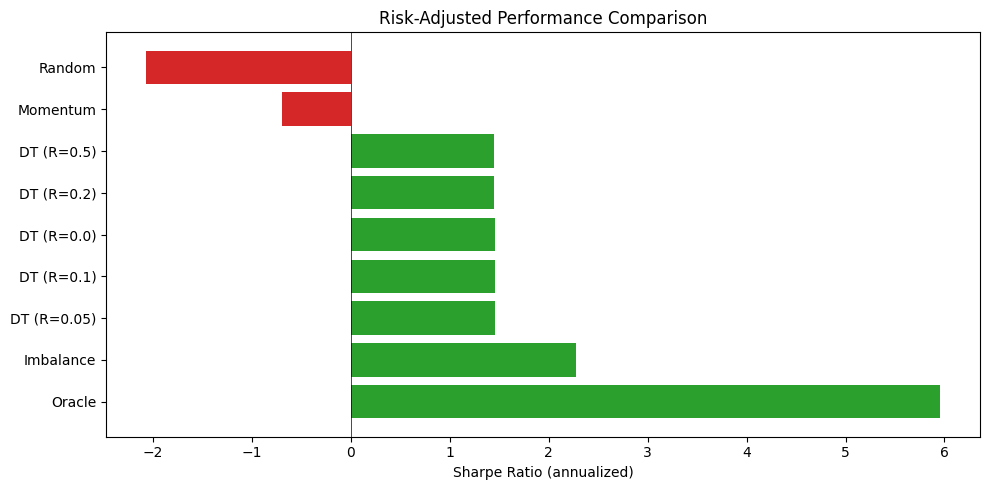

BACKTEST SUMMARY
  Oracle               | PnL: +9.240404 | Sharpe: +5.96 | MaxDD: 0.000000
  Imbalance            | PnL: +3.088457 | Sharpe: +2.27 | MaxDD: 0.476669
  DT (R=0.05)          | PnL: +1.213244 | Sharpe: +1.45 | MaxDD: 0.542394
  DT (R=0.1)           | PnL: +1.213244 | Sharpe: +1.45 | MaxDD: 0.542394
  DT (R=0.0)           | PnL: +1.212264 | Sharpe: +1.45 | MaxDD: 0.542394
  DT (R=0.2)           | PnL: +1.210301 | Sharpe: +1.45 | MaxDD: 0.544356
  DT (R=0.5)           | PnL: +1.209318 | Sharpe: +1.45 | MaxDD: 0.543863
  Momentum             | PnL: -0.011766 | Sharpe: -0.70 | MaxDD: 0.038743
  Random               | PnL: -2.756007 | Sharpe: -2.07 | MaxDD: 2.794747


In [29]:
# -- Sharpe ratio bar chart --
fig, ax = plt.subplots(figsize=(10, 5))

agents = df_metrics.index.tolist()
sharpes = df_metrics["Sharpe"].values
colors = ["tab:green" if s > 0 else "tab:red" for s in sharpes]

ax.barh(agents, sharpes, color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Sharpe Ratio (annualized)")
ax.set_title("Risk-Adjusted Performance Comparison")
plt.tight_layout()
plt.show()

# -- Final summary --
print("=" * 60)
print("BACKTEST SUMMARY")
print("=" * 60)
for _, row in df_metrics.iterrows():
    print(f"  {row.name:<20} | PnL: {row['PnL']:+.6f} | Sharpe: {row['Sharpe']:+.2f} | MaxDD: {row['MaxDD']:.6f}")
print("=" * 60)